# 01 — Datenexploration und Preprocessing

Ziel: finale Datensatzstruktur, Klassenverteilung und Kategorieverteilung untersuchen. Preprocessing, Labelregeln und Data-Quality-Checks dokumentieren.

**Labelregeln:**
- `edible`: sicher essbar, darf optisch unperfekt sein.
- `non_edible`: Schimmel, Schleim, deutliche Fäule oder starke Verderbnis.

### Aufbau
1. Datenquellen
2. Gesamtverteilung
3. Kategorieverteilung
4. Schwache Kategorien
5. Data-Quality-Checks
6. Dataset-Rebuild-Logik
7. Beispielbilder & Resize
8. Optionales Batch-Preprocessing

In [1]:
from pathlib import Path
import json
import math
import hashlib
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, UnidentifiedImageError

try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except ImportError:
    pass

def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Projekt-Root nicht gefunden.")

PROJECT_ROOT = find_project_root()
DATA_DIR     = PROJECT_ROOT / "data"
TRAIN_DIR    = DATA_DIR / "train"
VAL_DIR      = DATA_DIR / "val"
REPORTS_DIR  = PROJECT_ROOT / "reports"
MODELS_DIR   = PROJECT_ROOT / "models"
FINAL_MODEL  = MODELS_DIR / "freshify_baseline_with_new_raw.keras"
IMAGE_RESIZE_SCRIPT = PROJECT_ROOT / "scripts" / "image_resize.py"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".heic"}
CATEGORIES = ["banane", "erdbeere", "gurke", "orange", "paprika", "zitrone"]

plt.style.use("default")
pd.set_option("display.max_colwidth", 120)

## Inputs

Die folgenden Dateien und Ordner werden im Notebook verwendet:

In [2]:
pd.DataFrame([
    {"Input": "data/train", "Pfad": str(TRAIN_DIR.relative_to(PROJECT_ROOT)), "vorhanden": TRAIN_DIR.exists()},
    {"Input": "data/val", "Pfad": str(VAL_DIR.relative_to(PROJECT_ROOT)), "vorhanden": VAL_DIR.exists()},
    {"Input": "dataset_manifest", "Pfad": "reports/dataset_manifest.csv", "vorhanden": (REPORTS_DIR / "dataset_manifest.csv").exists()},
    {"Input": "training_findings", "Pfad": "reports/training_findings.md", "vorhanden": (REPORTS_DIR / "training_findings.md").exists()},
    {"Input": "image_resize_script", "Pfad": "scripts/image_resize.py", "vorhanden": IMAGE_RESIZE_SCRIPT.exists()},
])

,Input,Pfad,vorhanden
0,data/train,data/train,True
1,data/val,data/val,True
2,dataset_manifest,reports/dataset_manifest.csv,True
3,training_findings,reports/training_findings.md,True
4,image_resize_script,scripts/image_resize.py,True


## 1. Datenquellen

Alle verwendeten externen Datensätze und Quellen:

In [3]:
pd.DataFrame([
    {"Quelle": "https://www.kaggle.com/datasets/ulnnproject/food-freshness-dataset",
     "Verwendung": "Basisdatensatz für essbare und nicht essbare Lebensmittel"},
    {"Quelle": "https://www.kaggle.com/datasets/yusufemir/lemon-quality-dataset",
     "Verwendung": "Ergänzung für Zitrone"},
    {"Quelle": "https://www.kaggle.com/datasets/abdulbasit31/strawberry-dataset",
     "Verwendung": "Ergänzung für Erdbeere"},
    {"Quelle": "https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images",
     "Verwendung": "Ergänzende frische/verdorbene Obstbilder"},
    {"Quelle": "https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
     "Verwendung": "Ergänzung für Gurke/Paprika und weitere Fresh-vs-Rotten-Beispiele"},
    {"Quelle": "Pexels",
     "Verwendung": "Einzelne ergänzende Bilder für edible/zitrone"},
    {"Quelle": "Eigene Smartphonebilder",
     "Verwendung": "Zusätzliche realistischere non_edible Beispiele, inzwischen in data/train/ übernommen"},
])

,Quelle,Verwendung
0,https://www.kaggle.com/datasets/ulnnproject/food-freshness-dataset,Basisdatensatz für essbare und nicht essbare Lebensmittel
1,https://www.kaggle.com/datasets/yusufemir/lemon-quality-dataset,Ergänzung für Zitrone
2,https://www.kaggle.com/datasets/abdulbasit31/strawberry-dataset,Ergänzung für Erdbeere
3,https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images,Ergänzende frische/verdorbene Obstbilder
4,https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten,Ergänzung für Gurke/Paprika und weitere Fresh-vs-Rotten-Beispiele
5,Pexels,Einzelne ergänzende Bilder für edible/zitrone
6,Eigene Smartphonebilder,"Zusätzliche realistischere non_edible Beispiele, inzwischen in data/train/ übernommen"


In [4]:
def image_files(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

def infer_label(path):
    parts = [p.lower() for p in Path(path).parts]
    if "non_edible" in parts:
        return "non_edible"
    if "edible" in parts:
        return "edible"
    return "unknown"

def infer_category(path):
    text = str(path).lower()
    aliases = {
        "banane":   ["banane", "banana"],
        "erdbeere": ["erdbeere", "strawberry"],
        "gurke":    ["gurke", "cucumber"],
        "orange":   ["orange"],
        "paprika":  ["paprika", "pepper", "bell_pepper"],
        "zitrone":  ["zitrone", "lemon"],
    }
    for category, keys in aliases.items():
        if any(k in text for k in keys):
            return category
    return "unknown"

records = []
for split, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR)]:
    for path in image_files(split_dir):
        records.append({
            "split":    split,
            "label":    infer_label(path),
            "category": infer_category(path),
            "path":     str(path.relative_to(PROJECT_ROOT)),
        })

images_df = pd.DataFrame(records)
images_df.head()

,split,label,category,path
0,train,edible,banane,data/train/edible/banane/banana-e-k (1).png
1,train,edible,banane,data/train/edible/banane/banana-e-k (10).png
2,train,edible,banane,data/train/edible/banane/banana-e-k (11).png
3,train,edible,banane,data/train/edible/banane/banana-e-k (13).png
4,train,edible,banane,data/train/edible/banane/banana-e-k (14).png


## 2. Gesamtverteilung pro Split

`data/val/` ist klein; einzelne Fehlklassifikationen verschieben Accuracy, Precision und Recall sichtbar.

In [5]:
summary = (
    images_df.groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["split", "label"])
) if not images_df.empty else pd.DataFrame(columns=["split", "label", "count"])
summary

,split,label,count
0,train,edible,265
1,train,non_edible,215
2,val,edible,34
3,val,non_edible,28


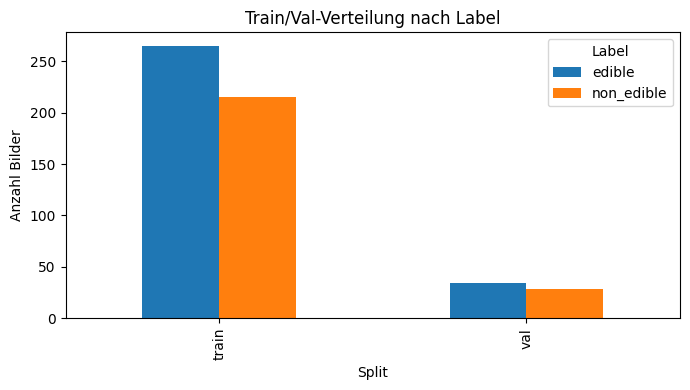

In [6]:
if not summary.empty:
    pivot = summary.pivot(index="split", columns="label", values="count").fillna(0)
    ax = pivot.plot(kind="bar", figsize=(7, 4))
    ax.set_title("Train/Val-Verteilung nach Label")
    ax.set_xlabel("Split")
    ax.set_ylabel("Anzahl Bilder")
    ax.legend(title="Label")
    plt.tight_layout()
    plt.show()

## 3. Kategorieverteilung pro Split, Label und Kategorie

Abgedeckte Kategorien: Banane, Erdbeere, Gurke, Orange, Paprika, Zitrone.

In [7]:
category_summary = (
    images_df.groupby(["split", "label", "category"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["split", "label", "category"])
) if not images_df.empty else pd.DataFrame(columns=["split", "label", "category", "count"])
category_summary

,split,label,category,count
0,train,edible,banane,78
1,train,edible,erdbeere,27
2,train,edible,gurke,42
3,train,edible,orange,54
4,train,edible,paprika,37
5,train,edible,zitrone,27
6,train,non_edible,banane,47
7,train,non_edible,erdbeere,23
8,train,non_edible,gurke,36
9,train,non_edible,orange,42


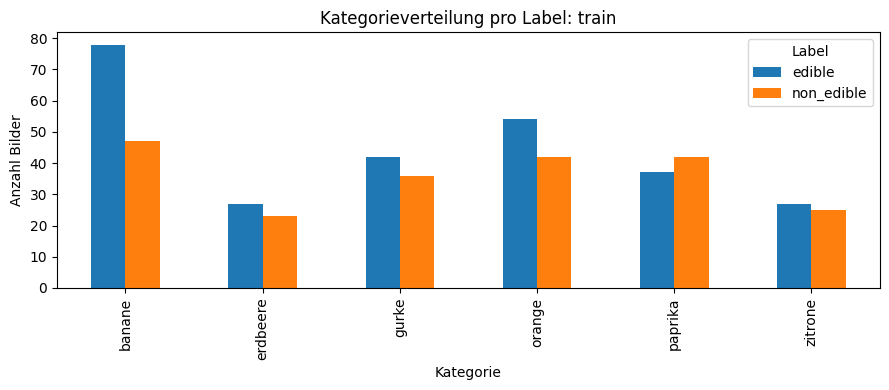

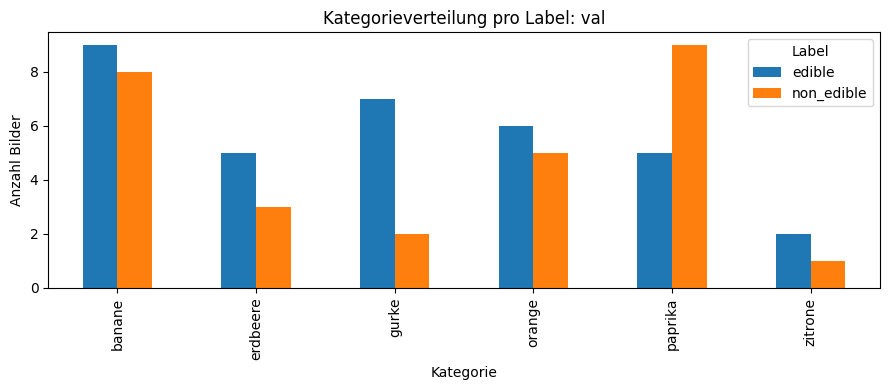

In [8]:
for split in ["train", "val"]:
    data = category_summary[category_summary["split"] == split]
    if data.empty:
        continue
    pivot = data.pivot_table(index="category", columns="label", values="count", fill_value=0)
    ax = pivot.reindex(CATEGORIES + ["unknown"]).dropna(how="all").plot(kind="bar", figsize=(9, 4))
    ax.set_title(f"Kategorieverteilung pro Label: {split}")
    ax.set_xlabel("Kategorie")
    ax.set_ylabel("Anzahl Bilder")
    ax.legend(title="Label")
    plt.tight_layout()
    plt.show()

## 4. Schwache Kategorien

Kategorien mit kleiner Datenmenge, kleiner Val-Menge oder Hinweisen aus `reports/training_findings.md`.

In [9]:
findings_path = REPORTS_DIR / "training_findings.md"
findings_text = findings_path.read_text(encoding="utf-8", errors="replace") if findings_path.exists() else ""

weak_rows = []
if not category_summary.empty:
    pivot = category_summary.pivot_table(
        index=["label", "category"], columns="split", values="count", fill_value=0
    )
    for (label, category), row in pivot.iterrows():
        train_count = int(row.get("train", 0))
        val_count   = int(row.get("val", 0))
        reasons = []
        if train_count < 30:
            reasons.append("kleine Datenmenge")
        if val_count < 5:
            reasons.append("kleine Val-Menge")
        if category != "unknown" and category.lower() in findings_text.lower():
            reasons.append("Hinweis in training_findings.md")
        if reasons:
            weak_rows.append({
                "label":       label,
                "category":    category,
                "train_count": train_count,
                "val_count":   val_count,
                "hinweise":    "; ".join(reasons),
            })

pd.DataFrame(weak_rows)

,label,category,train_count,val_count,hinweise
0,edible,banane,78,9,Hinweis in training_findings.md
1,edible,erdbeere,27,5,kleine Datenmenge; Hinweis in training_findings.md
2,edible,gurke,42,7,Hinweis in training_findings.md
3,edible,orange,54,6,Hinweis in training_findings.md
4,edible,paprika,37,5,Hinweis in training_findings.md
5,edible,zitrone,27,2,kleine Datenmenge; kleine Val-Menge; Hinweis in training_findings.md
6,non_edible,banane,47,8,Hinweis in training_findings.md
7,non_edible,erdbeere,23,3,kleine Datenmenge; kleine Val-Menge; Hinweis in training_findings.md
8,non_edible,gurke,36,2,kleine Val-Menge; Hinweis in training_findings.md
9,non_edible,orange,42,5,Hinweis in training_findings.md


## 5. Data-Quality-Checks

- nicht-lesbare Bilder
- Nicht-Bild-Dateien
- exakte Duplikate (SHA-256)
- Train-Val-Duplikate

In [10]:
all_files = []
for split, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR)]:
    if split_dir.exists():
        for path in sorted(p for p in split_dir.rglob("*") if p.is_file()):
            all_files.append((split, path))

unreadable = []
non_images = []
hashes     = defaultdict(list)

for split, path in all_files:
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        non_images.append(str(path.relative_to(PROJECT_ROOT)))
        continue
    try:
        with Image.open(path) as img:
            img.verify()
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hashes[digest].append((split, str(path.relative_to(PROJECT_ROOT))))
    except (UnidentifiedImageError, OSError, ValueError):
        unreadable.append(str(path.relative_to(PROJECT_ROOT)))

exact_duplicates    = {d: items for d, items in hashes.items() if len(items) > 1}
train_val_duplicates = {
    d: items for d, items in exact_duplicates.items()
    if {"train", "val"}.issubset({s for s, _ in items})
}

pd.DataFrame([
    {"check": "nicht-lesbare Bilder",  "count": len(unreadable),        "examples": unreadable[:5]},
    {"check": "Nicht-Bild-Dateien",    "count": len(non_images),        "examples": non_images[:5]},
    {"check": "exakte Duplikate",      "count": len(exact_duplicates),  "examples": list(exact_duplicates.values())[:3]},
    {"check": "Train-Val-Duplikate",   "count": len(train_val_duplicates), "examples": list(train_val_duplicates.values())[:3]},
])

,check,count,examples
0,nicht-lesbare Bilder,0,[]
1,Nicht-Bild-Dateien,0,[]
2,exakte Duplikate,0,[]
3,Train-Val-Duplikate,0,[]


## 6. Dataset-Rebuild-Logik aus `src/data.py`

Der echte Rebuild erfolgt nur per CLI — `python src/data.py`. Dieser Block dokumentiert die Schritte, ohne `data/` zu verändern.

In [11]:
dataset_builder_path = PROJECT_ROOT / "src" / "data.py"
train_path           = PROJECT_ROOT / "src" / "train.py"

print(f"Dataset-Builder vorhanden: {dataset_builder_path.exists()} ({dataset_builder_path})")
print(f"Training-Code vorhanden:   {train_path.exists()} ({train_path})")

rebuild_logic = pd.DataFrame([
    {"Schritt": "Quellen sammeln",
     "Beschreibung": "collect_structured_records, collect_raw_records und collect_background_aug_records sammeln die Bildquellen."},
    {"Schritt": "Kategorie ableiten",
     "Beschreibung": "infer_category_from_path nutzt Dateiname oder Elternordner und die im Dataset-Code verwendeten Kategorie-Aliase."},
    {"Schritt": "Hash berechnen",
     "Beschreibung": "compute_sha256 erkennt exakte Duplikate; compute_average_hash unterstützt Near-Duplicate-Cluster."},
    {"Schritt": "Deduplikation",
     "Beschreibung": "dedupe_records priorisiert structured vor raw vor background_aug bei identischem SHA-256."},
    {"Schritt": "Split-Zuweisung",
     "Beschreibung": "assign_splits hält Near-Duplicate-Cluster pro Label/Kategorie im gleichen Split."},
    {"Schritt": "Background-Aug",
     "Beschreibung": "background_aug wird explizit immer train zugeordnet."},
    {"Schritt": "Manifest",
     "Beschreibung": "write_manifest schreibt reports/dataset_manifest.csv mit split, label, category, source_type, source_path, output_path, sha256 und average_hash."},
])

rebuild_logic

Dataset-Builder vorhanden: True (/Users/timwalther/food_freshness/src/data.py)
Training-Code vorhanden:   True (/Users/timwalther/food_freshness/src/train.py)


,Schritt,Beschreibung
0,Quellen sammeln,"collect_structured_records, collect_raw_records und collect_background_aug_records sammeln die Bildquellen."
1,Kategorie ableiten,infer_category_from_path nutzt Dateiname oder Elternordner und die im Dataset-Code verwendeten Kategorie-Aliase.
2,Hash berechnen,compute_sha256 erkennt exakte Duplikate; compute_average_hash unterstützt Near-Duplicate-Cluster.
3,Deduplikation,dedupe_records priorisiert structured vor raw vor background_aug bei identischem SHA-256.
4,Split-Zuweisung,assign_splits hält Near-Duplicate-Cluster pro Label/Kategorie im gleichen Split.
5,Background-Aug,background_aug wird explizit immer train zugeordnet.
6,Manifest,"write_manifest schreibt reports/dataset_manifest.csv mit split, label, category, source_type, source_path, output_pa..."


In [12]:
manifest_path = REPORTS_DIR / "dataset_manifest.csv"
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    display(manifest.head())
    display(
        manifest.groupby(["split", "label", "category", "source_type"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["split", "label", "category", "source_type"])
    )
else:
    print(f"Manifest fehlt: {manifest_path}")

,split,label,category,source_type,source_path,output_path,sha256,average_hash
0,train,edible,banane,structured,data/train/edible/banane/banana-e-k (1).png,data/train/edible/banane/banana-e-k (1).png,c41d107bb098eae8e7b234aecd9da3afaea075244cd08a974686e8ea3696f5a0,18374403372710018814
1,train,edible,banane,structured,data/train/edible/banane/banana-e-k (10).png,data/train/edible/banane/banana-e-k (10).png,a90d4b49b0de35afd79a28e4d62b462731e7c7753c6940c48e85cb90c8b908dd,18429723116298564607
2,train,edible,banane,structured,data/train/edible/banane/banana-e-k (11).png,data/train/edible/banane/banana-e-k (11).png,2e9ee8880b3b374fbb0361db53e22df3e8c3418a322c7dac1bcfbf00dafc09d7,18446607186667885031
3,train,edible,banane,structured,data/train/edible/banane/banana-e-k (13).png,data/train/edible/banane/banana-e-k (13).png,510c243b343ff8710c8a0bd93c1286616cf8940325d804fabb9c812060d26680,18446682378677008701
4,train,edible,banane,structured,data/train/edible/banane/banana-e-k (14).png,data/train/edible/banane/banana-e-k (14).png,13bfdea65363cb96e57c9228a4c85dc067c89d25346bd2d5e4f65efbd4ec4081,18444767143093403650


,split,label,category,source_type,count
0,train,edible,banane,structured,78
1,train,edible,erdbeere,structured,27
2,train,edible,gurke,structured,42
3,train,edible,orange,structured,54
4,train,edible,paprika,structured,37
5,train,edible,zitrone,structured,27
6,train,non_edible,banane,structured,47
7,train,non_edible,erdbeere,structured,23
8,train,non_edible,gurke,structured,36
9,train,non_edible,orange,structured,42


## 7. Beispielbilder & Resize auf 224 × 224

Das Modell (`train.py`) lädt alle Bilder über `image_dataset_from_directory` mit `image_size=(224, 224)`, was einem direkten Resize entspricht.

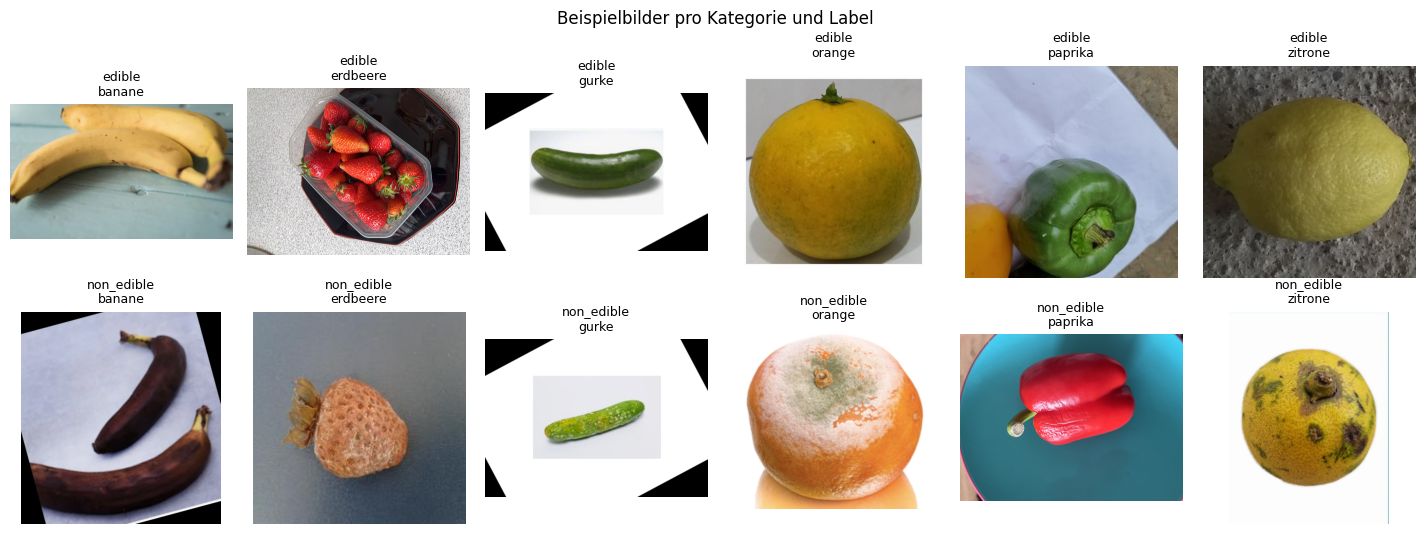

In [13]:
def show_sample_grid(df, max_per_row=6):
    if df.empty:
        print("Keine Bilddaten gefunden.")
        return
    sample_rows = []
    for label in ["edible", "non_edible"]:
        for category in CATEGORIES:
            subset = df[(df["label"] == label) & (df["category"] == category)]
            if not subset.empty:
                sample_rows.append(subset.iloc[0])
    if not sample_rows:
        print("Keine passenden Beispielbilder gefunden.")
        return
    n    = len(sample_rows)
    cols = min(max_per_row, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.7))
    axes = np.array(axes).reshape(-1)
    for ax, row in zip(axes, sample_rows):
        path = PROJECT_ROOT / row["path"]
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(f'{row["label"]}\n{row["category"]}', fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Beispielbilder pro Kategorie und Label")
    plt.tight_layout()
    plt.show()

show_sample_grid(images_df)

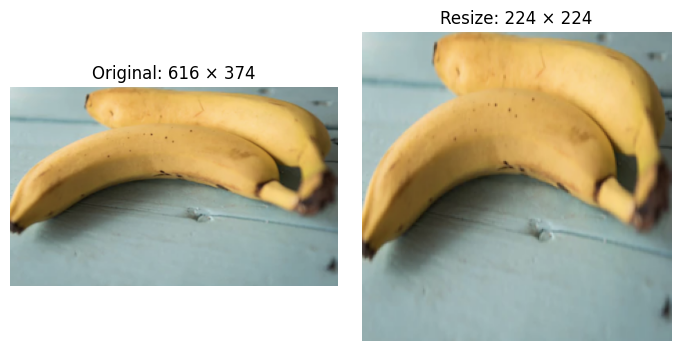

In [14]:
if not images_df.empty:
    sample_path = PROJECT_ROOT / images_df.iloc[0]["path"]
    original    = Image.open(sample_path).convert("RGB")
    resized     = original.resize((224, 224))
    fig, axes   = plt.subplots(1, 2, figsize=(7, 3.5))
    axes[0].imshow(original)
    axes[0].set_title(f"Original: {original.size[0]} × {original.size[1]}")
    axes[1].imshow(resized)
    axes[1].set_title("Resize: 224 × 224")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Kein Beispielbild verfügbar.")

## 8. Optionales Batch-Preprocessing externer Rohbilder

Das operative Resize-Skript liegt in `scripts/image_resize.py`. Dieser Abschnitt dokumentiert den Zweck, ohne externe Pfade auszuführen oder Dateien zu verändern.

Für neue Rohbilder: Pfade im Skript bewusst prüfen, Zielordner setzen und erst dann lokal ausführen.

In [15]:
pd.DataFrame([
    {"Skript": "scripts/image_resize.py", "vorhanden": IMAGE_RESIZE_SCRIPT.exists()},
    {"Parameter": "SIZE", "Wert": 224},
    {"Parameter": "QUALITY", "Wert": 85},
    {"Hinweis": "Das Skript enthält lokale Rohbild-Pfade und sollte nicht ungeprüft aus dem Notebook heraus ausgeführt werden."},
])

,Skript,vorhanden,Parameter,Wert,Hinweis
0,scripts/image_resize.py,True,NaN,NaN,NaN
1,NaN,NaN,SIZE,224.0,NaN
2,NaN,NaN,QUALITY,85.0,NaN
3,NaN,NaN,NaN,NaN,Das Skript enthält lokale Rohbild-Pfade und sollte nicht ungeprüft aus dem Notebook heraus ausgeführt werden.


## Optionaler Import vorsortierter Bilder

Dieser Abschnitt zeigt nur, wie ein Importplan aussehen würde. Das Notebook kopiert oder verschiebt keine Dateien.

In [17]:
SORTED_SRC_EXAMPLE = Path("path/to/sorted_images")
TRAIN_EDIBLE_DST   = TRAIN_DIR / "edible"

def next_numeric_counter(dst: Path):
    if not dst.exists():
        return 1
    nums = [int(m.group()) for f in dst.iterdir() if f.is_file() and (m := re.search(r"\d+", f.name))]
    return max(nums, default=0) + 1

def numbered_name(original_name: str, counter: int):
    stem   = Path(original_name).stem
    suffix = Path(original_name).suffix.lower()
    stem   = re.sub(r"\d+", str(counter), stem, count=1) if re.search(r"\d+", stem) else f"{stem}_{counter}"
    return f"{stem}{suffix}"

def preview_sorted_import(src=SORTED_SRC_EXAMPLE, dst=TRAIN_EDIBLE_DST):
    src, dst = Path(src), Path(dst)
    files = sorted(p for p in src.iterdir() if p.is_file()) if src.exists() else []
    counter  = next_numeric_counter(dst)
    plan     = []
    for p in files:
        target = dst / numbered_name(p.name, counter)
        plan.append({"src": str(p), "dst": str(target), "action": "copy"})
        counter += 1
    return pd.DataFrame(plan)

preview_sorted_import()

""


### Interpretation

- **Val-Set klein:** Die genaue Größe wird oben aus `data/val/` berechnet; bei dieser Größenordnung verschieben einzelne Fehlklassifikationen Accuracy, Recall und FN sichtbar.
- **`new_raw` kein Holdout mehr:** Die Smartphonebilder sind inzwischen Teil von `data/train/`. Für belastbare Real-World-Metriken wird ein neuer unabhängiger Holdout mit `edible` und `non_edible` benötigt.
- **Priorität Datenerweiterung:** Kategorien mit kleiner Train-Menge, kleiner Val-Menge oder auffälligen Fehlerhinweisen sollten priorisiert erweitert werden.